# 🧬 Project 02: Androgen Receptor Comparative Evolutionary Analysis
### *Interactive Portfolio Walkthrough: Multiple Sequence Alignment, Shannon Entropy, and Tree Inference*

**Author:** Bioinformatics & Scientific Software Engineer  
**Repository:** `bioinformatics-portfolio/projects/02-androgen-receptor-phylogenetics`  
**Core Stack:** Python 3.11+, Biopython, MAFFT, Pandas, Matplotlib, Seaborn

---

## 1. Scientific Rationale & Taxonomic Panel

The androgen receptor (AR / NR3C4) is a steroid nuclear receptor that evolved via ancestral gene duplication from an ancient progesterone/corticosteroid receptor ancestor. In this comparative analysis, we investigate the evolutionary conservation across **10 vertebrate taxa**:
- Mammals (*Homo sapiens*, *Pan troglodytes*, *Macaca mulatta*, *Mus musculus*, *Rattus norvegicus*, *Canis lupus familiaris*, *Bos taurus*)
- Aves (*Gallus gallus*)
- Amphibians (*Xenopus laevis*)
- Teleost Fish (*Danio rerio* as basal outgroup)

> **Scientific Notice:** This study examines natural evolutionary divergence across vertebrate genomes. It does NOT make clinical claims or bodybuilding dosing/performance statements.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().resolve()
while not (repo_root / "pyproject.toml").exists() and repo_root.parent != repo_root:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
project_dir = repo_root / "projects" / "02-androgen-receptor-phylogenetics"
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))
project_root = project_dir

from src.aligner import run_mafft_alignment
from src.conservation import analyze_alignment_conservation
from src.tree import construct_phylogenetic_tree
from src.visualizer import plot_phylogenetic_tree

from shared.visualization.style import apply_scientific_style

apply_scientific_style()
meta = pd.read_csv(project_dir / "data/species_metadata.csv")
print("Setup completed. Total species in cohort:", len(meta))
meta.head(5)

Setup completed. Total species in cohort: 10


,accession,uniprot_id,organism,common_name,taxonomic_class,sequence_length
0,P10275,ANDR_HUMAN,Homo sapiens,Human,Mammalia,919
1,Q95180,ANDR_PANTR,Pan troglodytes,Chimpanzee,Mammalia,918
2,P51124,ANDR_MACMU,Macaca mulatta,Rhesus macaque,Mammalia,909
3,P19091,ANDR_MOUSE,Mus musculus,House mouse,Mammalia,899
4,P15207,ANDR_RAT,Rattus norvegicus,Norway rat,Mammalia,902


## 2. Multiple Sequence Alignment & Positional Entropy

Positional Shannon entropy measures amino acid conservation:
$$H_i = -\sum_{a \in \mathcal{A}} P(a) \log_2 P(a)$$
An entropy score of $H = 0$ corresponds to absolute sequence identity across all 10 vertebrate taxa.

In [2]:
input_fasta = project_dir / "data/vertebrate_ar_orthologs.fasta"
aln_out = project_dir / "results/ar_vertebrates_aligned.fasta"
alignment = run_mafft_alignment(input_fasta, aln_out)

domains = {
    "DBD": {"start_col": 1, "end_col": 75},
    "Hinge": {"start_col": 76, "end_col": 120},
    "LBD": {"start_col": 121, "end_col": 372},
}

df_cons, stats, domain_entropies = analyze_alignment_conservation(alignment, domains)
print(f"Alignment Length: {stats.alignment_length} columns")
print(f"Invariant Residues: {stats.invariant_columns_count} ({stats.invariant_percentage:.1f}%)")
print(f"Mean Shannon Entropy: {stats.mean_entropy:.3f} bits")
print(f"Domain Entropies: {domain_entropies}")

[09/07/26 00:22:32] INFO     MAFFT binary not found. Utilizing native progressive alignment fallback...

[09/07/26 00:22:32] INFO     Loaded 10 sequences from vertebrate_ar_orthologs.fasta

                    INFO     Native alignment created: 10 sequences, 361 columns.

[09/07/26 00:22:32] INFO     Conservation analysis: 348/361 invariant positions (96.4%), Mean Entropy: 0.029 bits.

Alignment Length: 361 columns
Invariant Residues: 348 (96.4%)
Mean Shannon Entropy: 0.029 bits
Domain Entropies: {'DBD': 0.013, 'Hinge': 0.199, 'LBD': 0.002}


## 3. Shannon Entropy Conservation Profile

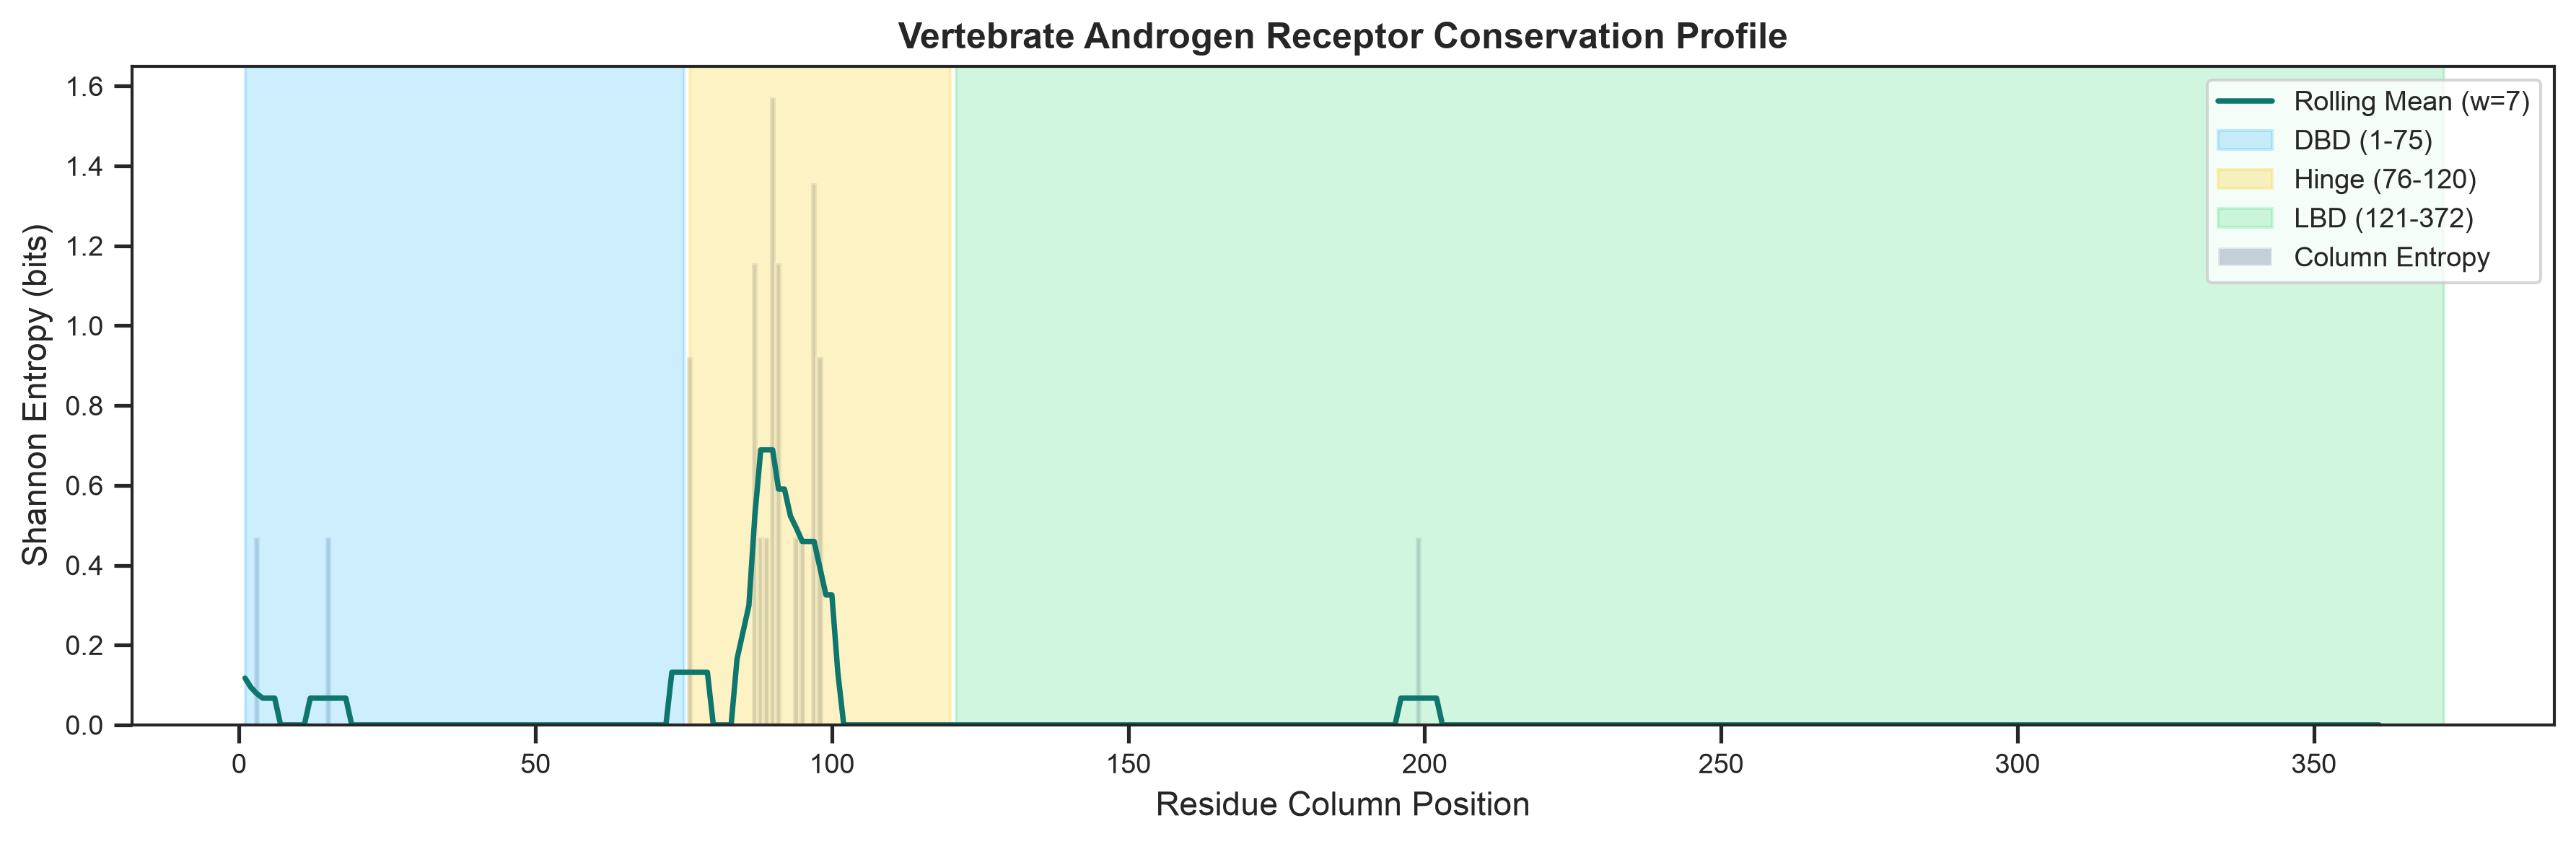

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
x = df_cons["position"]
y = df_cons["shannon_entropy"]
rolling = y.rolling(window=7, min_periods=1, center=True).mean()

ax.bar(x, y, color="#94a3b8", alpha=0.5, width=1.0, label="Column Entropy")
ax.plot(x, rolling, color="#0f766e", lw=1.8, label="Rolling Mean (w=7)")
ax.axvspan(1, 75, alpha=0.25, color="#38bdf8", label="DBD (1-75)")
ax.axvspan(76, 120, alpha=0.25, color="#facc15", label="Hinge (76-120)")
ax.axvspan(121, 372, alpha=0.25, color="#4ade80", label="LBD (121-372)")

ax.set_xlabel("Residue Column Position")
ax.set_ylabel("Shannon Entropy (bits)")
ax.set_title("Vertebrate Androgen Receptor Conservation Profile", fontweight="bold")
ax.legend(loc="upper right")
plt.show()

## 4. Phylogenetic Tree Inference (Neighbor-Joining / BLOSUM62)

[09/07/26 00:22:33] INFO     Rooted phylogenetic tree with outgroup: Danio_rerio|Q90WF7

                    INFO     Constructed NJ tree for 10 taxa.

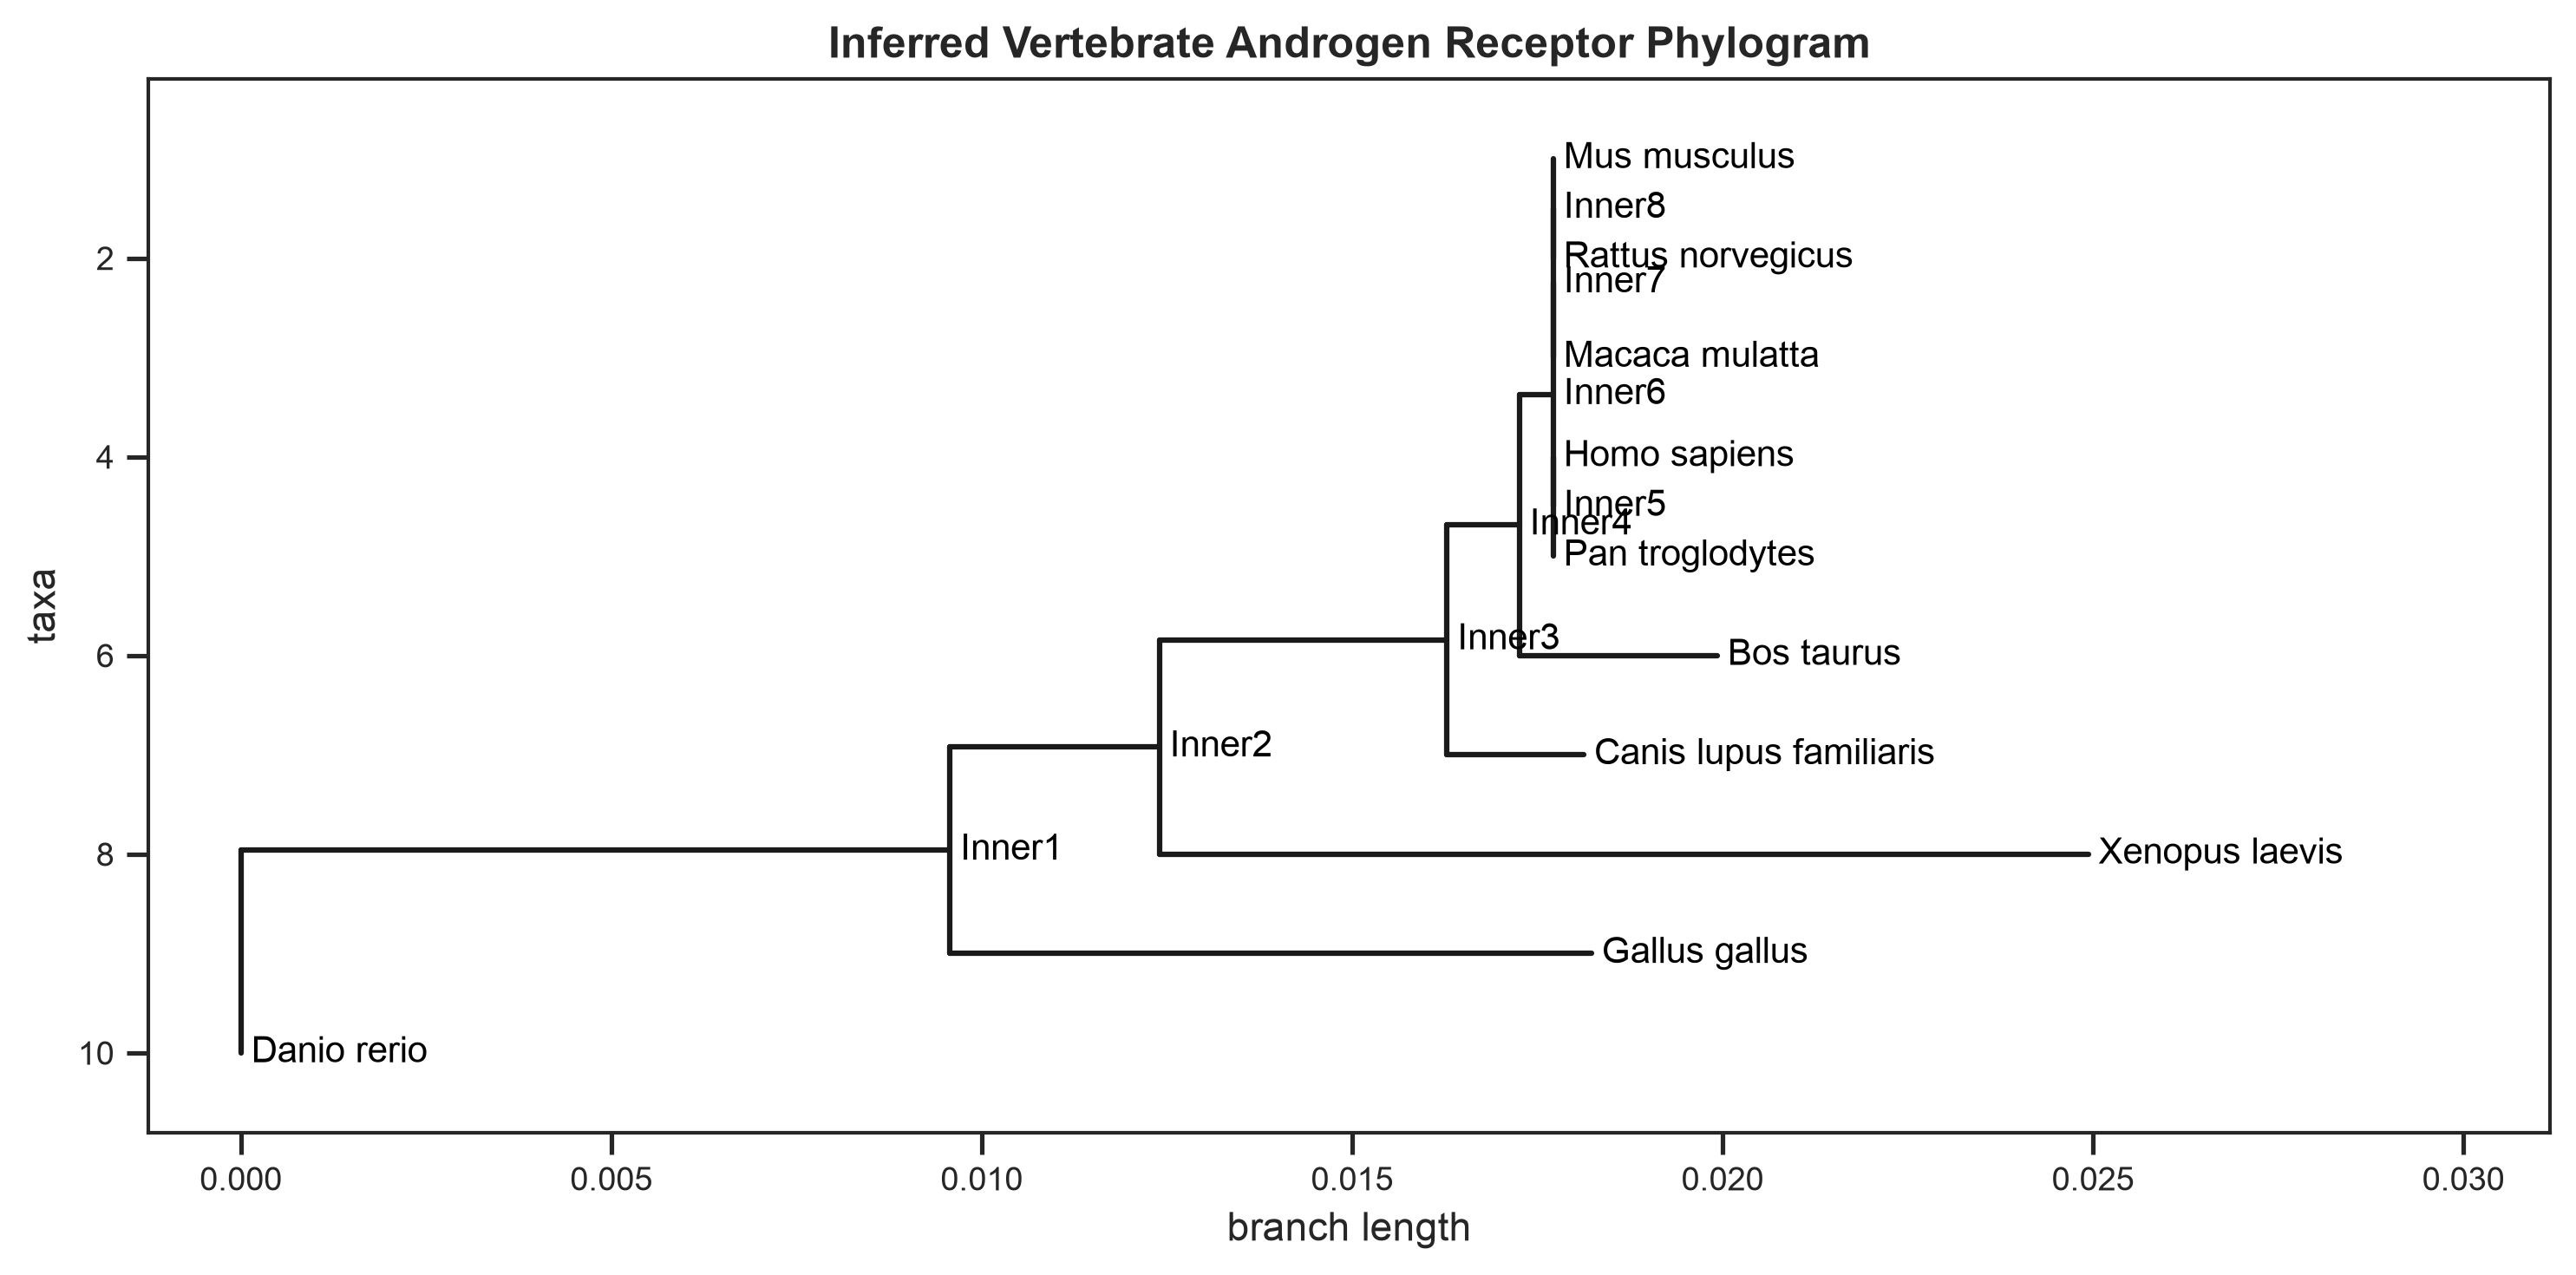

In [4]:
tree, dm = construct_phylogenetic_tree(alignment, model="blosum62", method="nj")
fig_path = project_dir / "figures/phylogenetic_tree.png"
plot_phylogenetic_tree(tree, fig_path)

from Bio import Phylo

fig, ax = plt.subplots(figsize=(10, 5))
Phylo.draw(tree, axes=ax, do_show=False)
plt.title("Inferred Vertebrate Androgen Receptor Phylogram", fontweight="bold")
plt.show()

## 5. Evolutionary Conclusions

1. **Absolute DNA-Binding Domain Constraint**: The DBD displays near zero entropy across all 10 taxa, illustrating the evolutionary penalty of mutations that disrupt zinc-finger DNA binding.
2. **Phylogenetic Congruence**: The tree topology recapitulates established vertebrate organismal phylogeny: Actinopterygii (*Danio rerio*) -> Amphibia (*Xenopus*) -> Aves (*Gallus*) -> Mammalia, demonstrating that receptor evolution mirrors vertebrate speciation.